In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Data preprocessing

In [99]:
df = pd.read_csv('sample_data/Titanic-Dataset.csv')

In [100]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [101]:
df.shape

(891, 12)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [103]:
# dropping these 3 columns cuz they are just strings and not relevant info for the model to learn
df = df.drop(columns = ['PassengerId', 'Name', 'Ticket'])

In [104]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


In [105]:
# dropping cabin cuz lots of null values (77.1%)
df = df.drop(columns = ['Cabin'])

In [106]:
# filling median age inplace of null values for balance
df['Age'].median()

28.0

In [107]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [108]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,2


In [109]:
# dropping those 2 rows which have null values in embarked
df = df.dropna(subset = ['Embarked'])

In [110]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


# Data analysis

In [111]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [112]:
# getting some statistical measures
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,0.382452,2.311586,29.315152,0.524184,0.382452,32.096681
std,0.486260,0.834700,12.984932,1.103705,0.806761,49.697504
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [113]:
# how many people survived and didnt survive
df['Survived'].value_counts()

,count
Survived,
0,549
1,340


# Data visualization

In [114]:
# survival by PClass
survival_by_pclass = df.groupby('Pclass')['Survived'].mean()
# saving this as a pandas series, grouping pclass into the 3 existing categories and telling pandas to only focus on the survived column
# since it will be in 0s and 1s, we need to find mean which will give %, also not directly plotting cuz 1 cat may survive more because it has more numbers
print(survival_by_pclass)

Pclass
1    0.626168
2    0.472826
3    0.242363
Name: Survived, dtype: float64


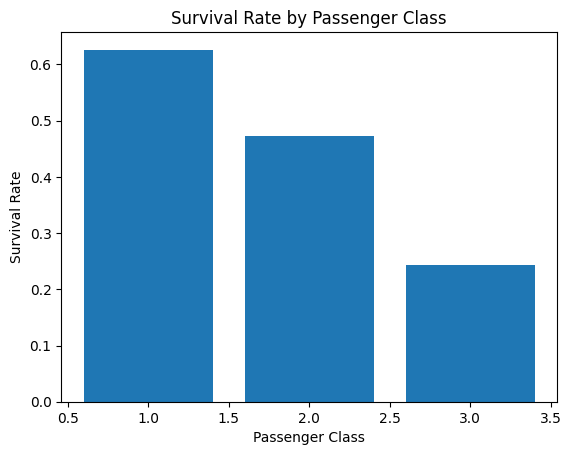

In [115]:
plt.bar(survival_by_pclass.index, survival_by_pclass.values)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Passenger Class")

plt.show()

so that passengers with class 1 survived more, so this column is pretty relevant

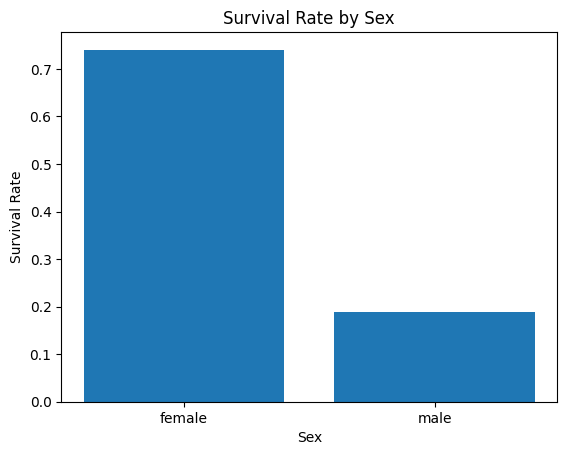

In [116]:
# survival by gender
survival_by_sex = df.groupby("Sex")["Survived"].mean()

plt.bar(survival_by_sex.index, survival_by_sex.values)

plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex")

plt.show()

females were given more priority

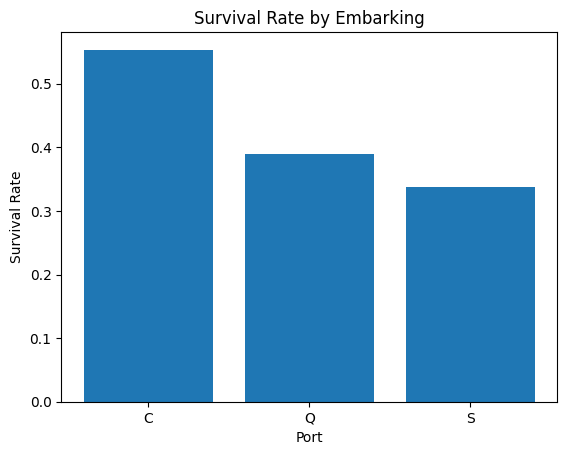

In [117]:
# survival by which port the embarked from
survival_by_embarked = df.groupby("Embarked")["Survived"].mean()

plt.bar(survival_by_embarked.index, survival_by_embarked.values)

plt.xlabel("Port")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Embarking")

plt.show()

shows that C (Cherbourg) people survived more, could also be because its in france, lots of rich people also indicated by Pclass

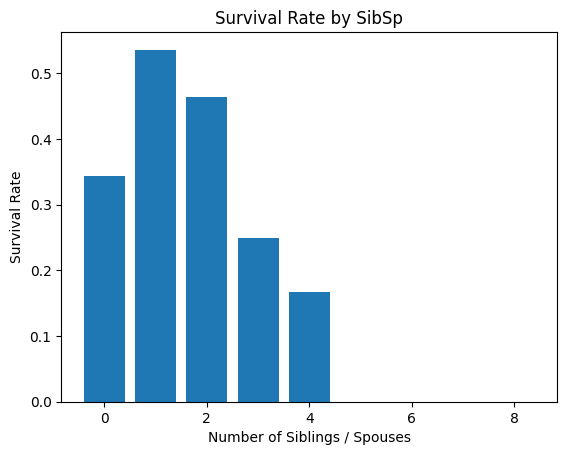

In [118]:
# survival by SibSp
survival_by_sibsp = df.groupby("SibSp")["Survived"].mean()

plt.bar(survival_by_sibsp.index, survival_by_sibsp.values)

plt.xlabel("Number of Siblings / Spouses")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by SibSp")

plt.show()

not necesarily showing more siblings = more survival rate but its still pretty relevant

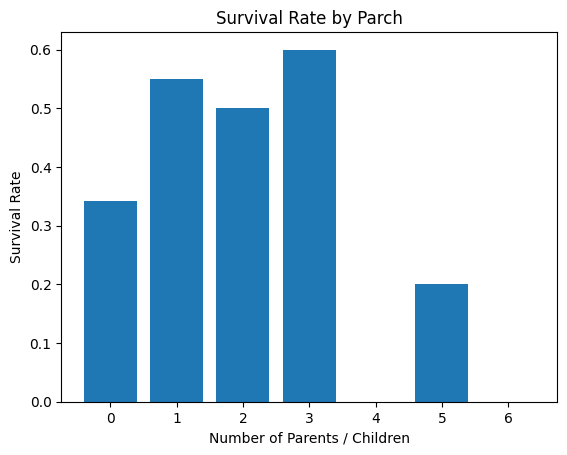

In [119]:
# survival by parents & children

survival_by_parch = df.groupby("Parch")["Survived"].mean()

plt.bar(survival_by_parch.index, survival_by_parch.values)

plt.xlabel("Number of Parents / Children")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Parch")

plt.show()

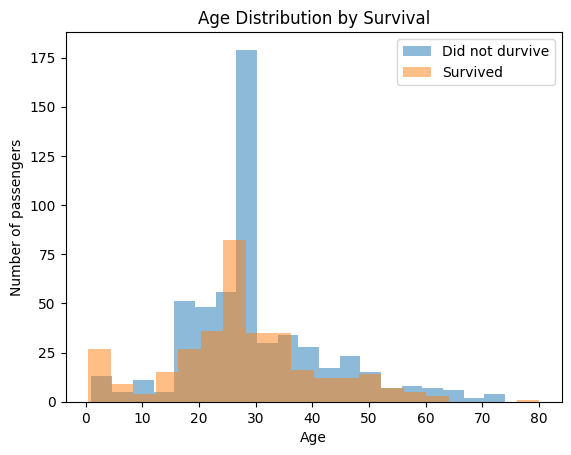

In [120]:
# survival by age
plt.hist(
    df[df["Survived"] == 0]["Age"],
    bins=20,
    alpha=0.5,
    label="Did not durvive"
)

plt.hist(
    df[df["Survived"] == 1]["Age"],
    bins=20,
    alpha=0.5,
    label="Survived"
)

plt.xlabel("Age")
plt.ylabel("Number of passengers")
plt.title("Age Distribution by Survival")
plt.legend()

plt.show()

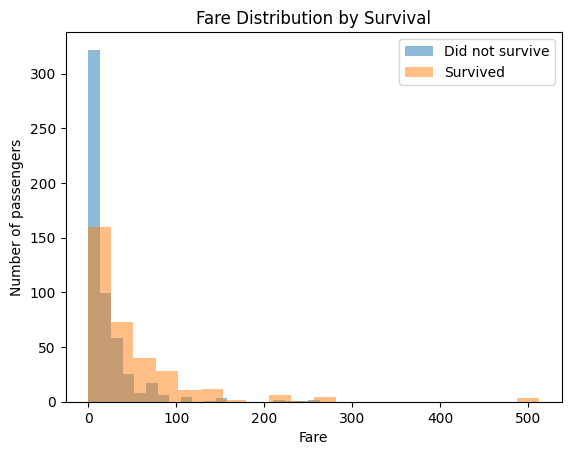

In [121]:
# survival by fare

plt.hist(
    df[df["Survived"] == 0]["Fare"],
    bins=20,
    alpha=0.5,
    label="Did not survive"
)

plt.hist(
    df[df["Survived"] == 1]["Fare"],
    bins=20,
    alpha=0.5,
    label="Survived"
)

plt.xlabel("Fare")
plt.ylabel("Number of passengers")
plt.title("Fare Distribution by Survival")
plt.legend()

plt.show()

# Encoding the columns

In [122]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,312


In [123]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [124]:
# Encoding categorical columns
# using one hot encoding to avoid biases

df['Sex'] = df['Sex'].replace({
    'male': 0,
    'female': 1
})

df = pd.get_dummies(
    df,
    columns=['Embarked'],
    dtype=int
)

/tmp/ipykernel_655/42153668.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex'] = df['Sex'].replace({


In [125]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1


# Seperating features & target

In [126]:
X = df.drop(columns = ['Survived'], axis = 1)
Y = df['Survived']

In [127]:
print(X)

     Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_C  Embarked_Q  \
0         3    0  22.0      1      0   7.2500           0           0   
1         1    1  38.0      1      0  71.2833           1           0   
2         3    1  26.0      0      0   7.9250           0           0   
3         1    1  35.0      1      0  53.1000           0           0   
4         3    0  35.0      0      0   8.0500           0           0   
..      ...  ...   ...    ...    ...      ...         ...         ...   
886       2    0  27.0      0      0  13.0000           0           0   
887       1    1  19.0      0      0  30.0000           0           0   
888       3    1  28.0      1      2  23.4500           0           0   
889       1    0  26.0      0      0  30.0000           1           0   
890       3    0  32.0      0      0   7.7500           0           1   

     Embarked_S  
0             1  
1             0  
2             1  
3             1  
4             1  
..          ...

In [131]:
print(Y)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 889, dtype: int64


# Splitting data into training and testing

In [132]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

In [133]:
print(X.shape, X_train.shape, X_test.shape)

(889, 9) (711, 9) (178, 9)


# Model training (Logistic regression)

In [149]:
model = LogisticRegression(max_iter=1000)

In [150]:
model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

In [151]:
X_train_prediction = model.predict(X_train)
X_test_prediction = model.predict(X_test)

In [152]:
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)

In [153]:
print('Accuracy score of training data : ', training_data_accuracy)
print('Accuracy score of test data : ', test_data_accuracy)

Accuracy score of training data :  0.8045007032348804
Accuracy score of test data :  0.7921348314606742


# Model Training (Random Forest)

In [144]:
from sklearn.ensemble import RandomForestClassifier

In [145]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=2)

In [146]:
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=2)

In [147]:
rf_train_prediction = rf_model.predict(X_train)
rf_test_prediction = rf_model.predict(X_test)

In [148]:
rf_training_accuracy = accuracy_score(
    Y_train,
    rf_train_prediction
)

rf_test_accuracy = accuracy_score(
    Y_test,
    rf_test_prediction
)

print('Random Forest training accuracy:', rf_training_accuracy)
print('Random Forest test accuracy:', rf_test_accuracy)

Random Forest training accuracy: 0.9817158931082982
Random Forest test accuracy: 0.8089887640449438


# Model Comparison

| Model | Training Accuracy | Test Accuracy |
|---|---:|---:|
| Logistic Regression | 80.45% | 79.21% |
| Random Forest | 98.17% | 80.90% |

Random Forest has slightly a higher test accuracy than Logistic Regression.
But its training accuracy is much higher than its test accuracy,
so its overfitting.

Logistic Regression has a much smaller difference between training and
test accuracy, so it is better generalized.

# Standard Scaling

doing this to see if scaling makes any changed to logistic regression

In [154]:
from sklearn.preprocessing import StandardScaler

In [163]:
# using standard scaler to automatically calculate parameters

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression after scaling

In [162]:
scaled_logistic_model = LogisticRegression(max_iter=1000)

scaled_logistic_model.fit(X_train_scaled, Y_train)

LogisticRegression(max_iter=1000)

In [158]:
scaled_logistic_train_prediction = scaled_logistic_model.predict(X_train_scaled)

scaled_logistic_test_prediction = scaled_logistic_model.predict(X_test_scaled)

In [159]:
print("Scaled Logistic Regression training accuracy:", accuracy_score(Y_train, scaled_logistic_train_prediction))

print("Scaled Logistic Regression test accuracy:", accuracy_score(Y_test, scaled_logistic_test_prediction))

Scaled Logistic Regression training accuracy: 0.8059071729957806
Scaled Logistic Regression test accuracy: 0.7921348314606742


not re-trainig random forest since random forests makes its parameters on the basis on tiny decisions like age>30? gender=female? etc...Scaling doesnt change anything since it'll just make decisions on the scaled data unlike logistic regression which relies purely on numbers and calculations

# Evaluation

### Precision, Recall, F1

In [165]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [166]:
print("LOGISTIC REGRESSION")
print(classification_report(Y_test, scaled_logistic_test_prediction))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       111
           1       0.72      0.73      0.73        67

    accuracy                           0.79       178
   macro avg       0.78      0.78      0.78       178
weighted avg       0.79      0.79      0.79       178



In [167]:
print("RANDOM FOREST")
print(classification_report(Y_test, rf_test_prediction))

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       111
           1       0.75      0.73      0.74        67

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.80       178
weighted avg       0.81      0.81      0.81       178



precision is basically, if model predicts 100ppl survived, but actually only 84 did, then precision is 84/100 = 84%

recall is basically, if actually 100ppl survived, but model predicted 80 of them, recall is 80/100 = 80% (model managed to find 80% of the actual survivers)

f1 score is like a balance between precision and recall to give a final score to model

### Confusion Matrices

In [168]:
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(Y_test, scaled_logistic_test_prediction))

Logistic Regression Confusion Matrix:
[[92 19]
 [18 49]]


In [169]:
print("Random Forest Confusion Matrix:")
print(confusion_matrix(Y_test, rf_test_prediction))

Random Forest Confusion Matrix:
[[95 16]
 [18 49]]


# K-fold Cross Validation

now f1 score, precision, recall only gives metrics on 1 particular train-test split. but suppose that train-test split didnt have ideal distributions. so to test our model properly we distribute the train-test split into multiple scenerios to check its consistency on different train-test splits (folding the data into 5 boxes and using 1 box out of that 5 for testing is what gives it its name

| Round | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 |
|---|---|---|---|---|---|
| **Round 1** | 🟥 **TEST** | 🟩 TRAIN | 🟩 TRAIN | 🟩 TRAIN | 🟩 TRAIN |
| **Round 2** | 🟩 TRAIN | 🟥 **TEST** | 🟩 TRAIN | 🟩 TRAIN | 🟩 TRAIN |
| **Round 3** | 🟩 TRAIN | 🟩 TRAIN | 🟥 **TEST** | 🟩 TRAIN | 🟩 TRAIN |
| **Round 4** | 🟩 TRAIN | 🟩 TRAIN | 🟩 TRAIN | 🟥 **TEST** | 🟩 TRAIN |
| **Round 5** | 🟩 TRAIN | 🟩 TRAIN | 🟩 TRAIN | 🟩 TRAIN | 🟥 **TEST** |

In [170]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [187]:
# dividing data for cross validation and storing format in cv
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=2
)

### Cross valdation for logistic regression

In [188]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_cv_scores = cross_val_score(
    logistic_model,
    X,
    Y,
    cv=cv,
    scoring='accuracy'
)

# cross_val_score() basically takes model, X, Y, then does CV, stores each accuracy score in a list

print("Logistic Regression CV scores:")
print(logistic_cv_scores)

print("Logistic Regression mean CV accuracy:",
      logistic_cv_scores.mean())

print("Logistic Regression CV standard deviation:",
      logistic_cv_scores.std())

Logistic Regression CV scores:
[0.84269663 0.74157303 0.81460674 0.79213483 0.79096045]
Logistic Regression mean CV accuracy: 0.7963943375864915
Logistic Regression CV standard deviation: 0.03325248782596946


### Cross validation for Random Forests

In [185]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=2
)

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    Y,
    cv=cv,
    scoring='accuracy'
)

print("Random Forest CV scores:")
print(rf_cv_scores)

print("Random Forest mean CV accuracy:",
      rf_cv_scores.mean())

print("Random Forest CV standard deviation:",
      rf_cv_scores.std())

Random Forest CV scores:
[0.83146067 0.76966292 0.7752809  0.8258427  0.83050847]
Random Forest mean CV accuracy: 0.8065511331175014
Random Forest CV standard deviation: 0.02794699119523793


# Final Comparison

In [186]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],

    'Training Accuracy': [
        accuracy_score(Y_train, scaled_logistic_train_prediction),
        rf_training_accuracy
    ],

    'Test Accuracy': [
        accuracy_score(Y_test, scaled_logistic_test_prediction),
        rf_test_accuracy
    ],

    'Mean CV Accuracy': [
        logistic_cv_scores.mean(),
        rf_cv_scores.mean()
    ],

    'CV Std': [
        logistic_cv_scores.std(),
        rf_cv_scores.std()
    ]
})

comparison

,Model,Training Accuracy,Test Accuracy,Mean CV Accuracy,CV Std
0,Logistic Regression,0.805907,0.792135,0.796394,0.033252
1,Random Forest,0.981716,0.808989,0.806551,0.027947


### Conclusion

Random Forest is the current best performing model based on both test
accuracy and mean 5-fold cross-validation accuracy.

- Random Forest Test Accuracy: 80.90%
- Logistic Regression Test Accuracy: 79.21%
- Random Forest Mean CV Accuracy: 80.66%
- Logistic Regression Mean CV Accuracy: 79.64%

However, Random Forest has a large gap between its training accuracy
(98.17%) and test accuracy (80.90%), so its clearly overfitting

Still, Random Forest is the current best-performing model based on comparing purely test results, but
hyperparameter tuning should be performed in a future iteration to
reduce overfitting since random forest algorithms are known for memorization with default parameters.